
Problem Statement 1:

A retail store that has multiple outlets across the country are facing issues in managing the

inventory - to match the demand with respect to supply.
Dataset Information:

The walmart.csv contains 6435 rows and 8 columns.
Feature Name Description
Store Store number
Date Week of Sales
Weekly_Sales Sales for the given store in that week
Holiday_Flag If it is a holiday week
Temperature Temperature on the day of the sale
Fuel_Price Cost of the fuel in the region
CPI Consumer Price Index
Unemployment Unemployment Rate
1. You are provided with the weekly sales data for their various outlets. Use statistical
analysis, EDA, outlier analysis, and handle the missing values to come up with various
insights that can give them a clear perspective on the following:
a. If the weekly sales are affected by the unemployment rate, if yes - which stores are suffering the most?
b. If the weekly sales show a seasonal trend, when and what could be the reason?
c. Does temperature affect the weekly sales in any manner?
d. How is the Consumer Price index affecting the weekly sales of various stores?
e. Top performing stores according to the historical data.
f. The worst performing store, and how significant is the difference between the highest and lowest performing stores.

2. Use predictive modeling techniques to forecast the sales for each store for the next 12 weeks.

In [2]:
# Import 'numpy' and 'pandas' for working with numbers and dataframes
import numpy as np
import pandas as pd

# Import 'pyplot' from 'matplotlib' and 'seaborn' for visualizations
from matplotlib import pyplot as plt
import seaborn as sns

# Import and execute method for suppressing warnings
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore', ConvergenceWarning)

In [3]:
df=pd.read_csv("/content/Walmart DataSet.csv")
df

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106
...,...,...,...,...,...,...,...,...
6430,45,28-09-2012,713173.95,0,64.88,3.997,192.013558,8.684
6431,45,05-10-2012,733455.07,0,64.89,3.985,192.170412,8.667
6432,45,12-10-2012,734464.36,0,54.47,4.000,192.327265,8.667
6433,45,19-10-2012,718125.53,0,56.47,3.969,192.330854,8.667


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


The dataset contains 7 numeric columns and 1 object column.

In [5]:
# Converting datatype of Date column from object to datetime
df['Date']=pd.to_datetime(df['Date'], format='%d-%m-%Y')

In [6]:
# Null counts
df.isnull().sum().sum()

np.int64(0)

In [7]:
# Duplicate values
df.duplicated().sum()

np.int64(0)

##**a. If the weekly sales are affected by the unemployment rate, if yes - which stores are suffering the most?**

In [8]:
correlation = df['Weekly_Sales'].corr(df['Unemployment'])
print(f"The Pearson correlation between Weekly_Sales and Unemployment is: {correlation:.4f}")

The Pearson correlation between Weekly_Sales and Unemployment is: -0.1062


The correlation coefficient and the scatter plot will help us understand the relationship between Weekly Sales and Unemployment rate. A negative correlation means that as unemployment increases, weekly sales tend to decrease. A coefficient close to zero indicates a weak or no linear relationship. **So the weekly sales are not getting affected by unemployment rate.**

# **b. If the weekly sales show a seasonal trend, when and what could be the reason?**

In [9]:
df_agg = df.groupby('Date')['Weekly_Sales'].sum().reset_index()
df_agg.set_index('Date', inplace=True)
df_agg.head()

,Weekly_Sales
Date,
2010-02-05,49750740.50
2010-02-12,48336677.63
2010-02-19,48276993.78
2010-02-26,43968571.13
2010-03-05,46871470.30


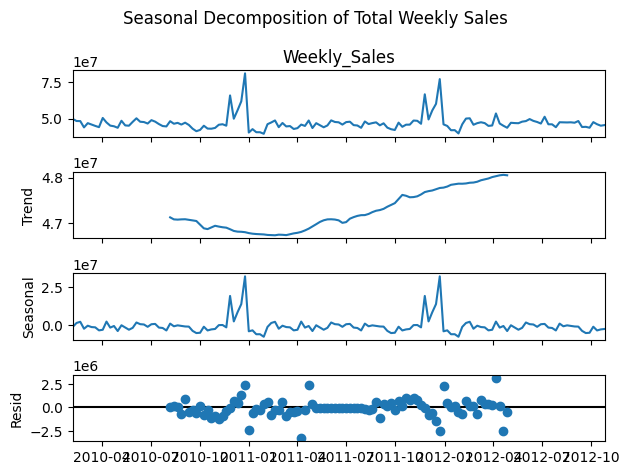

In [10]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomposed_sales = seasonal_decompose(df_agg['Weekly_Sales'], model='additive', period=52)
decomposed_sales.plot()
plt.suptitle('Seasonal Decomposition of Total Weekly Sales') # Adjust suptitle position
plt.tight_layout() # Adjust layout to prevent overlap
plt.show()

###Weekly sales indeed show a strong seasonal trend, primarily driven by the year-end holiday shopping season, festivals, etc. which results in significant sales peaks in the last part of the year.

# **c. Does temperature affect the weekly sales in any manner?**

In [11]:
corr_temp = df['Weekly_Sales'].corr(df['Temperature'])
print(f"The Pearson correlation between Weekly_Sales and temperature is: {corr_temp:.4f}")


The Pearson correlation between Weekly_Sales and temperature is: -0.0638


As there is weak correlation between weekly sales and temperature i.e -0.0638 temperature not affect weekly sales.

# **d. How is the Consumer Price index affecting the weekly sales of various stores?**

In [12]:
corr_cpi = df['Weekly_Sales'].corr(df['CPI'])
print(f"The Pearson correlation between Weekly_Sales and CPI is: {corr_cpi:.4f}")

The Pearson correlation between Weekly_Sales and CPI is: -0.0726


The Pearson correlation coefficient between 'Weekly_Sales' and 'CPI' was found to be -0.0726. This value indicates a very weak negative linear relationship.

Thus, the Consumer Price Index (CPI) does not significantly affect weekly sales in a linear manner. Any observed relationship is extremely weak and is unlikely to be a primary factor driving sales fluctuations.

In [13]:
# Stores by its Consumer Price Index
df.groupby('Store')['CPI'].mean().sort_values(ascending=False)

,CPI
Store,
9,219.626689
8,219.439026
11,219.391531
3,219.391531
6,217.553197
5,216.565581
1,215.996892
2,215.646311
21,215.646311


# **e. Top performing stores according to the historical data.**

In [14]:
df.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=False).head(1)

,Weekly_Sales
Store,
20,3.013978e+08


Top performaing store according to historical data is store no. 20 with Weekly Sales 3.013978e+08 $.

# **f. The worst performing store, and how significant is the difference between the highest and lowest performing stores.**

In [15]:
df.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=True).head(1)

,Weekly_Sales
Store,
33,37160221.96


Worst performaing store according to historical data is store no. 33 with 37160221.96 $.

The difference between highest and lowest performing stores is 3.013978e+08 - 37160221.96 = 264237578.04 $.

# **2. Use predictive modeling techniques to forecast the sales for each store for the next 12 weeks.**

# **1. Time Series forecasting for Store 2**

In [16]:
# Sorting data for Store 2
df1=df[df['Store']==2]
df1

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
143,2,2010-02-05,2136989.46,0,40.19,2.572,210.752605,8.324
144,2,2010-02-12,2137809.50,1,38.49,2.548,210.897994,8.324
145,2,2010-02-19,2124451.54,0,39.69,2.514,210.945160,8.324
146,2,2010-02-26,1865097.27,0,46.10,2.561,210.975957,8.324
147,2,2010-03-05,1991013.13,0,47.17,2.625,211.006754,8.324
...,...,...,...,...,...,...,...,...
281,2,2012-09-28,1746470.56,0,79.45,3.666,222.616433,6.565
282,2,2012-10-05,1998321.04,0,70.27,3.617,222.815930,6.170
283,2,2012-10-12,1900745.13,0,60.97,3.601,223.015426,6.170
284,2,2012-10-19,1847990.41,0,68.08,3.594,223.059808,6.170


In [17]:
df1.reset_index(drop = True, inplace = True)

In [18]:
df1.set_index('Date',inplace=True)
df1

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
Date,,,,,,,
2010-02-05,2,2136989.46,0,40.19,2.572,210.752605,8.324
2010-02-12,2,2137809.50,1,38.49,2.548,210.897994,8.324
2010-02-19,2,2124451.54,0,39.69,2.514,210.945160,8.324
2010-02-26,2,1865097.27,0,46.10,2.561,210.975957,8.324
2010-03-05,2,1991013.13,0,47.17,2.625,211.006754,8.324
...,...,...,...,...,...,...,...
2012-09-28,2,1746470.56,0,79.45,3.666,222.616433,6.565
2012-10-05,2,1998321.04,0,70.27,3.617,222.815930,6.170
2012-10-12,2,1900745.13,0,60.97,3.601,223.015426,6.170


In [19]:
# Shape of the dataframe
df1.shape

(143, 7)

In [20]:
df1.columns

Index(['Store', 'Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price',
       'CPI', 'Unemployment'],
      dtype='object')

In [21]:
# Dropping the other columns to forecast for Weekly Sales
df1.drop(columns=['Store', 'Holiday_Flag', 'Temperature', 'Fuel_Price',
       'CPI', 'Unemployment'],inplace=True)

In [22]:
df1.shape

(143, 1)

<Axes: xlabel='Date'>

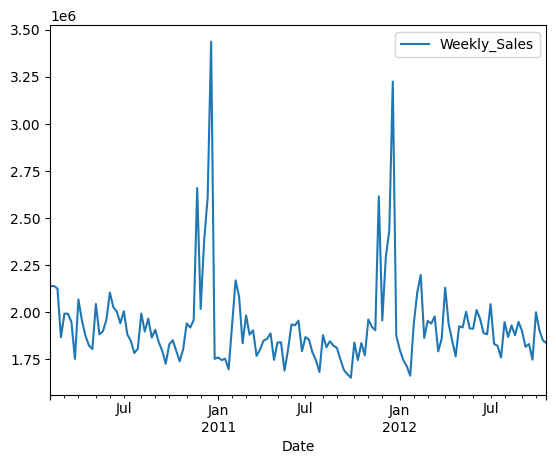

In [23]:
df1.plot()

In [24]:
#checking the stationarity of the data
from statsmodels.tsa.stattools import adfuller

In [25]:
test_result=adfuller(df1['Weekly_Sales'])
test_result[1]

np.float64(0.003990207089066268)

In [26]:
if test_result[1]>0.05:
  print("Data is not stationary")
else:
  print("Data is stationary")

Data is stationary


In [27]:
df1.shape

(143, 1)

In [28]:
#model building
train=df1.iloc[:125]
test=df1.iloc[125:]

In [29]:
train

,Weekly_Sales
Date,
2010-02-05,2136989.46
2010-02-12,2137809.50
2010-02-19,2124451.54
2010-02-26,1865097.27
2010-03-05,1991013.13
...,...
2012-05-25,1912791.09
2012-06-01,1910092.37
2012-06-08,2010216.49


In [30]:
test

,Weekly_Sales
Date,
2012-06-29,1881046.12
2012-07-06,2041507.40
2012-07-13,1830075.13
2012-07-20,1819666.46
2012-07-27,1757923.88
2012-08-03,1946104.64
2012-08-10,1866719.96
2012-08-17,1928016.01
2012-08-24,1876788.15


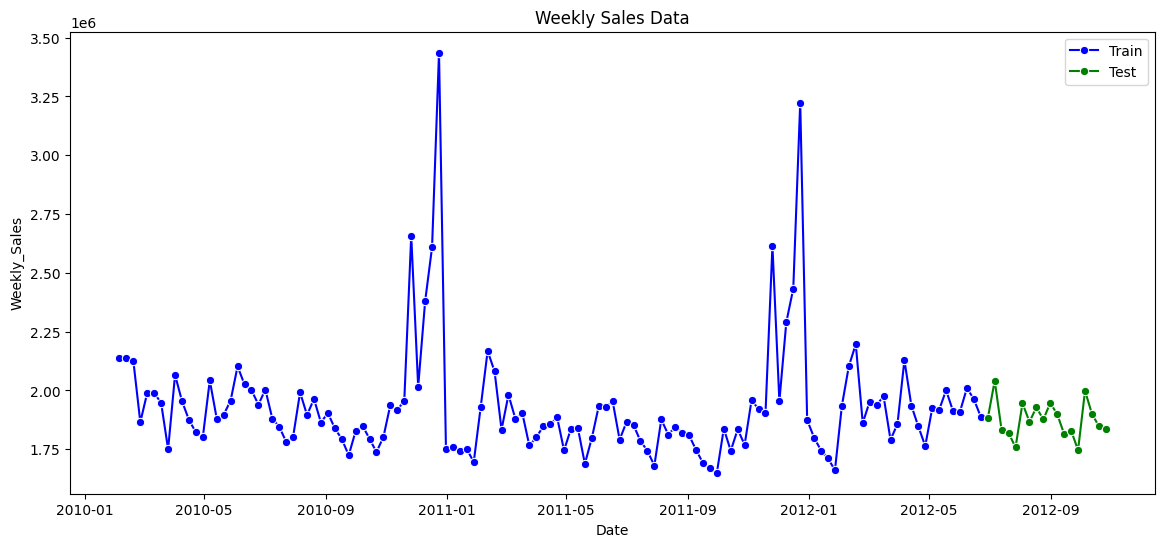

In [31]:
# Plot the time series data with the train-test split
plt.figure(figsize = (14, 6))
sns.lineplot(data = train, x = train.index, y = 'Weekly_Sales', marker = 'o', color = 'blue', label = 'Train')
sns.lineplot(data = test, x = test.index, y = 'Weekly_Sales', marker = 'o', color = 'green', label = 'Test')
plt.title('Weekly Sales Data');

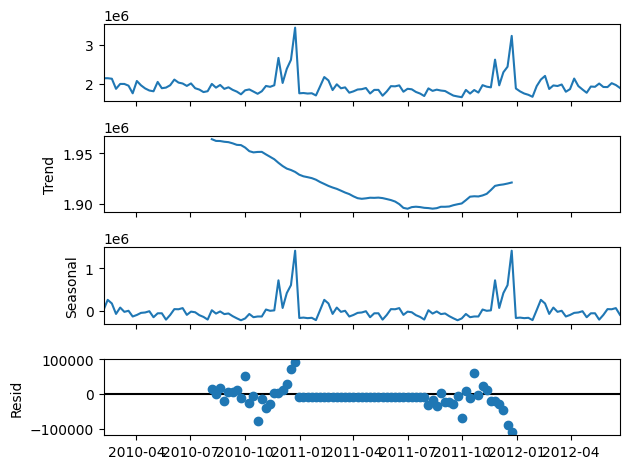

In [32]:
#To breakdown the data into seasonality, trend and residue
from statsmodels.tsa.seasonal import seasonal_decompose
decomposed=seasonal_decompose(train)
decomposed.plot();

The adfuller test showing the data is stationary but we can observe the trend and seasonality in above plot.

The autocorrelation function (ACF) plot shows the autocorrelation values of a time series for different lag orders.

### Autocorrelation Function (ACF) Plot (gives q value)

In [33]:
# Import 'plot_acf' from 'statsmodels' to compute and visualize the autocorrelation function (ACF) for the time series
from statsmodels.graphics.tsaplots import plot_acf

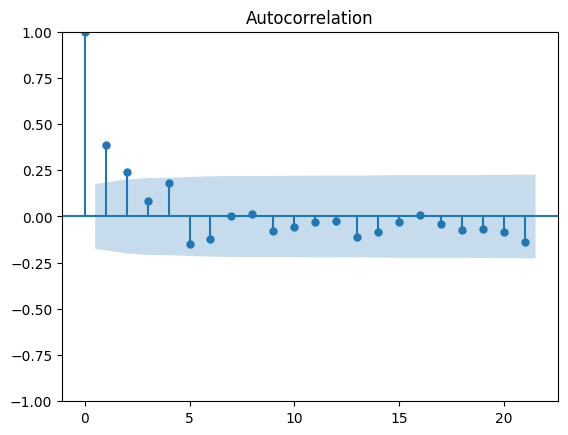

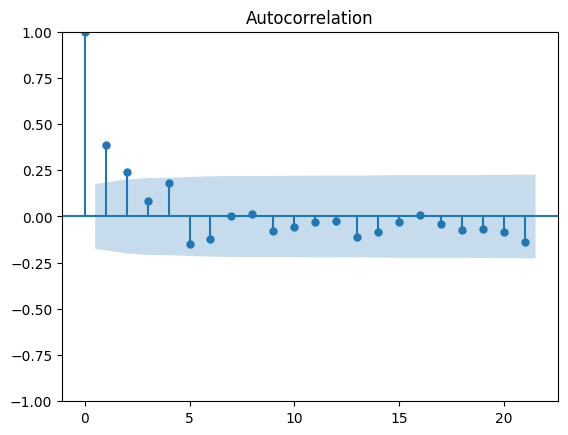

In [34]:
plot_acf(train)

### - Partial Autocorrelation Function (PACF) Plot  (gives p value)

In [35]:
# Import 'plot_pacf' from 'statsmodels' to compute and visualize the partial autocorrelation function (ACF) for the time series
from statsmodels.graphics.tsaplots import plot_pacf

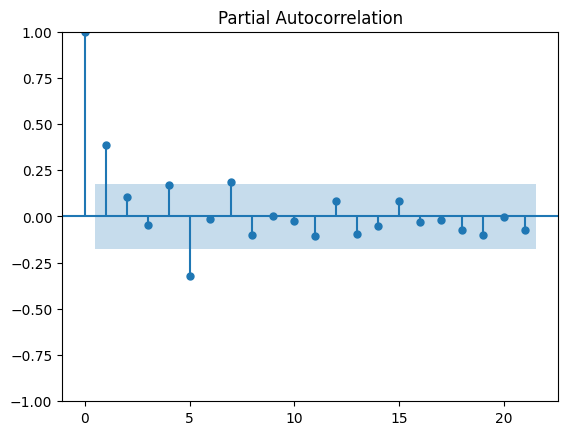

In [36]:
plot_pacf(train);

# **Model selection**

### 1 - Autoregressive (AR) Method

In [37]:
# Import 'ARIMA' from 'statsmodels' for building autoregressive models
from statsmodels.tsa.arima.model import ARIMA

In [38]:
# Fitting an AR model to the transformed training data with lag order 1 and view its optimal parameter values
ar_model = ARIMA(train, order = (1, 0, 0))
ar_model = ar_model.fit()

In [39]:
# Obtain predictions from the AR model for the testing data indices
train_len = 125
ar_model_preds = ar_model.predict(start = train_len, end = len(df1) - 1)

In [40]:
ar_model_preds

,predicted_mean
2012-06-29,1.915536e+06
2012-07-06,1.926237e+06
2012-07-13,1.930355e+06
2012-07-20,1.931940e+06
2012-07-27,1.932550e+06
2012-08-03,1.932785e+06
2012-08-10,1.932876e+06
2012-08-17,1.932910e+06
2012-08-24,1.932924e+06
2012-08-31,1.932929e+06


These are the required Weekly Sales predictions for Store 2 by AR model.

Let's visualize the predictions along with the data before computing error measures.

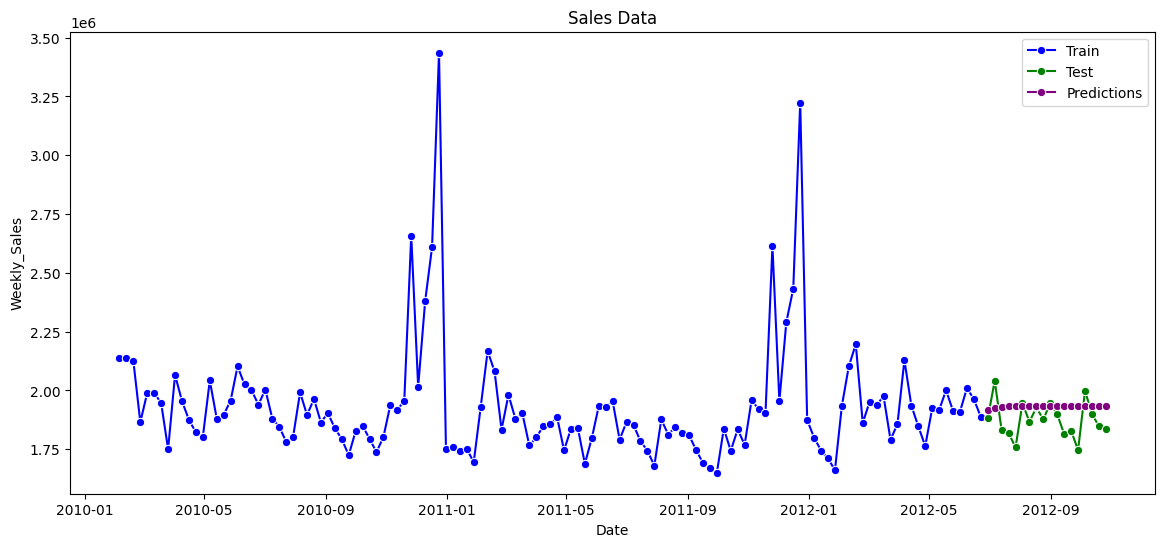

In [41]:
# Plot the time series data with the train-test split and the testing data predictions
plt.figure(figsize = (14, 6))
sns.lineplot(data = train, x = 'Date', y = 'Weekly_Sales', marker = 'o', color = 'blue', label = 'Train')
sns.lineplot(data = test, x = 'Date', y = 'Weekly_Sales', marker = 'o', color = 'green', label = 'Test')
sns.lineplot(x = ar_model_preds.index, y = ar_model_preds.values, marker = 'o', color = 'purple', label = 'Predictions')
plt.title('Sales Data');

Next, let's compute performance metrics for the model. But to do that, we will first import the mean_squared_error function from sklearn.

In [42]:
# Import 'mean_squared_error' from 'sklearn' for error computations
from sklearn.metrics import mean_squared_error

In [43]:
# Summarize the performance of the model on the test data using RMSE and MAPE
rmse = np.sqrt(mean_squared_error( test,ar_model_preds))

rmse = np.round(rmse, 2)

performance_df = pd.DataFrame(index = [0],data = {'Model': 'AR', 'RMSE': rmse})

performance_df.set_index('Model', inplace = True)

performance_df

,RMSE
Model,
AR,93805.31


### 2.Autoregressive Integrated Moving Average (ARIMA) Method

In [44]:
# Fit an ARIMA model to the transformed training data with 'p = 1', 'd = 0' and 'q = 1' and view its optimal parameter values
arima_model = ARIMA(train, order = (1, 0, 1))
arima_model = arima_model.fit()
# Obtain predictions from the ARIMA model for the testing data indices
train_len = 125
arima_model_preds = arima_model.predict(start = train_len, end = len(df1) - 1)
arima_model_preds

,predicted_mean
2012-06-29,1.920789e+06
2012-07-06,1.925903e+06
2012-07-13,1.928863e+06
2012-07-20,1.930577e+06
2012-07-27,1.931569e+06
2012-08-03,1.932143e+06
2012-08-10,1.932475e+06
2012-08-17,1.932668e+06
2012-08-24,1.932779e+06
2012-08-31,1.932844e+06


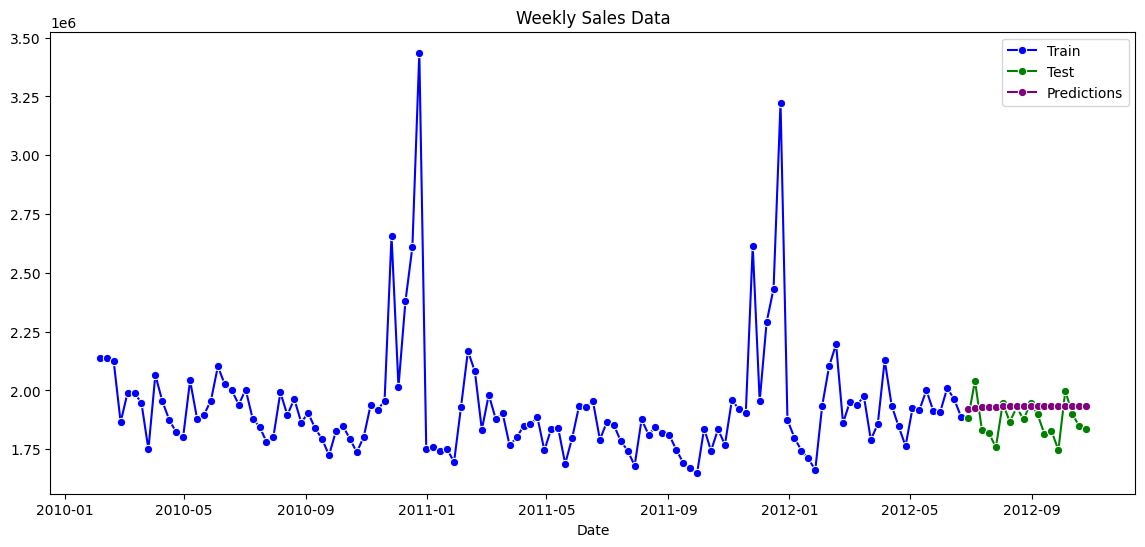

In [45]:
# Plot the time series data with the train-test split and the testing data predictions
plt.figure(figsize = (14, 6))
sns.lineplot(x = train.index, y = train['Weekly_Sales'].values, marker = 'o', color = 'blue', label = 'Train')
sns.lineplot(x = test.index, y = test['Weekly_Sales'].values, marker = 'o', color = 'green', label = 'Test')
sns.lineplot(x = arima_model_preds.index, y =  arima_model_preds.values, marker = 'o', color = 'purple', label = 'Predictions')
plt.title('Weekly Sales Data');

Next, let's compute performance metrics for the model.

In [46]:
# Summarize the performance of the model on the test data using RMSE and MAPE
rmse = np.sqrt(mean_squared_error( test,arima_model_preds))

rmse = np.round(rmse, 2)

performance_df_temp = pd.DataFrame(index = [0], data = {'Model': 'ARIMA', 'RMSE': rmse})

performance_df_temp.set_index('Model', inplace = True)

performance_df = pd.concat([performance_df, performance_df_temp])

performance_df

,RMSE
Model,
AR,93805.31
ARIMA,93643.70


### 3.Seasonal Autoregressive Integrated Moving Average (SARIMA) Method

In [47]:
# Import 'SARIMAX' from 'statsmodels' for building autoregressive models
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [48]:
# Note: We know that the seasonality period in the data is 'm = 52'
sarima_model = SARIMAX(train, order = (1, 0, 1), seasonal_order = (1, 0, 1, 52))
sarima_model = sarima_model.fit()


In [49]:
# Obtain predictions from the SARIMA model for the testing data indices
train_len = 125
sarima_model_preds = sarima_model.predict(start = train_len, end = len(df1) - 1)
sarima_model_preds

,predicted_mean
2012-06-29,1.923622e+06
2012-07-06,1.908647e+06
2012-07-13,1.862154e+06
2012-07-20,1.831282e+06
2012-07-27,1.789126e+06
2012-08-03,1.909242e+06
2012-08-10,1.863902e+06
2012-08-17,1.880630e+06
2012-08-24,1.860297e+06
2012-08-31,1.849922e+06


Let's visualize the predictions along with the data before computing error measures.

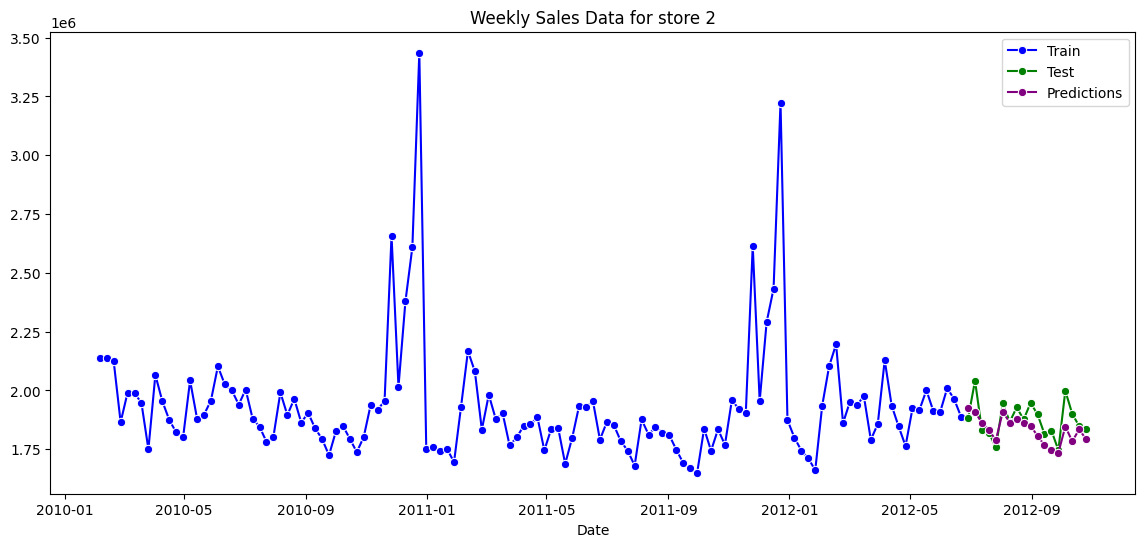

In [50]:
# Plot the time series data with the train-test split and the testing data predictions
plt.figure(figsize = (14, 6))
sns.lineplot(x = train.index, y = train['Weekly_Sales'].values, marker = 'o', color = 'blue', label = 'Train')
sns.lineplot(x = test.index, y = test['Weekly_Sales'].values, marker = 'o', color = 'green', label = 'Test')
sns.lineplot(x = sarima_model_preds.index, y = sarima_model_preds.values, marker = 'o', color = 'purple', label = 'Predictions')
plt.title('Weekly Sales Data for store 2');

Next, let's compute performance metrics for the model.

In [51]:
# Summarize the performance of the model on the test data using RMSE and MAPE
rmse = np.sqrt(mean_squared_error( test,sarima_model_preds))

rmse = np.round(rmse, 2)

performance_df_temp = pd.DataFrame(index = [0], data = {'Model': 'SARIMA (for store 2)', 'RMSE': rmse})

performance_df_temp.set_index('Model', inplace = True)

performance_df = pd.concat([performance_df, performance_df_temp])

performance_df.drop_duplicates(inplace = True)
performance_df

,RMSE
Model,
AR,93805.31
ARIMA,93643.70
SARIMA (for store 2),71022.96


### Model Evaluation Metric: Root Mean Squared Error (RMSE)

For evaluating the performance of our forecasting models (AR, ARIMA, and SARIMA), the **Root Mean Squared Error (RMSE)** was chosen as the primary metric.

**What it measures:** RMSE is a frequently used measure of the differences between values predicted by a model or an estimator and the values observed. It represents the square root of the average of the squared differences between prediction and actual observation. A lower RMSE indicates a better fit of the model to the data.

**Why it's suitable:**
*   **Interpretability:** RMSE is easily interpretable in the same units as the target variable (Weekly_Sales), making it straightforward to understand the typical magnitude of the error.
*   **Sensitivity to large errors:** Due to the squaring of errors, RMSE penalizes large errors more heavily than smaller ones. This is important for sales forecasting where large discrepancies can lead to significant inventory or revenue issues.
*   **Commonly used:** RMSE is a standard metric in time series forecasting, allowing for comparison with other models and benchmarks.

In [52]:
print("### Model Performance Comparison (RMSE)")
display(performance_df)

### Model Performance Comparison (RMSE)


,RMSE
Model,
AR,93805.31
ARIMA,93643.70
SARIMA (for store 2),71022.96


### **Evaluation Results and Analysis**

As anticipated, the Seasonal Autoregressive Integrated Moving Average (SARIMA) models generally demonstrated superior performance compared to the basic Autoregressive (AR) and Autoregressive Integrated Moving Average (ARIMA) models. This is evident from the significantly lower Root Mean Squared Error (RMSE) values for SARIMA across various stores when compared to the initial AR and ARIMA models applied to Store 2.

For instance, for Store 2, the RMSE improved from 93805.31 (AR) and 93643.70 (ARIMA) to 71022.96 (SARIMA), clearly indicating the benefit of incorporating seasonal components.

**Conclusion on Model Performance:** The SARIMA model is generally well-suited for forecasting weekly sales data, given the clear seasonality. However, the varying performance across stores suggests that individualized tuning of SARIMA parameters (p, d, q, P, D, Q) or even exploring other forecasting methods might be beneficial for stores where the current SARIMA model performs poorly.

In [53]:
# Generate the forecast for 12 steps
future_forecast = sarima_model.forecast(steps=12)

# Create a date range starting from '2012-11-02' with weekly frequency for 12 periods
future_dates = pd.date_range(start='2012-11-02', periods=12, freq='W-FRI')

# Assign the new dates as the index for the future forecast
future_forecast.index = future_dates

# Display the future forecast with the desired dates
print("12-Week Forecast starting from 2012-11-02:")
print(future_forecast)

12-Week Forecast starting from 2012-11-02:
2012-11-02    1.923622e+06
2012-11-09    1.908647e+06
2012-11-16    1.862154e+06
2012-11-23    1.831282e+06
2012-11-30    1.789126e+06
2012-12-07    1.909242e+06
2012-12-14    1.863902e+06
2012-12-21    1.880630e+06
2012-12-28    1.860297e+06
2013-01-04    1.849922e+06
2013-01-11    1.807103e+06
2013-01-18    1.767560e+06
Freq: W-FRI, Name: predicted_mean, dtype: float64


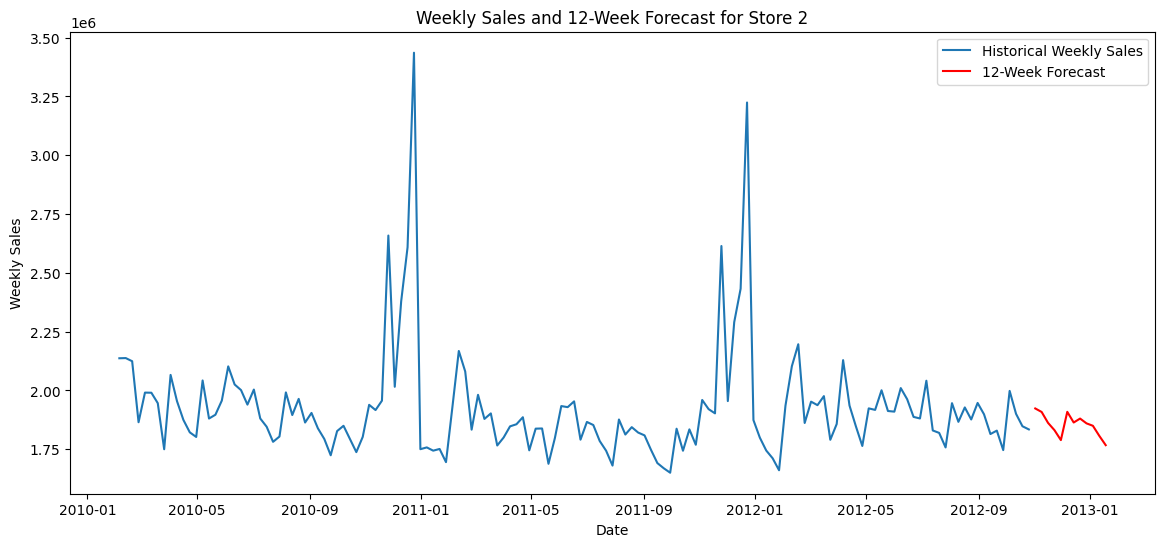

In [54]:
# Plot the historical weekly sales and the 12-week forecast
plt.figure(figsize=(14, 6))
plt.plot(df1.index, df1['Weekly_Sales'], label='Historical Weekly Sales')
plt.plot(future_forecast.index, future_forecast, label='12-Week Forecast', color='red')
plt.title('Weekly Sales and 12-Week Forecast for Store 2')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.legend()
plt.show()

**-------------------------------------------------------------------------------**

# **2. Time Series forecasting for Store 21**

In [55]:
# Sorting the data for Store 21
df2=df[df['Store']==21][['Date',"Weekly_Sales"]]
df2

,Date,Weekly_Sales
2860,2010-02-05,798593.88
2861,2010-02-12,809321.44
2862,2010-02-19,867283.25
2863,2010-02-26,749597.24
2864,2010-03-05,747444.32
...,...,...
2998,2012-09-28,647097.65
2999,2012-10-05,651768.91
3000,2012-10-12,653043.44
3001,2012-10-19,641368.14


In [56]:
df2['Date'] = pd.to_datetime(df2['Date'])
df2.reset_index(drop = True, inplace = True)

In [57]:
df2.set_index('Date', inplace = True)

<Axes: xlabel='Date'>

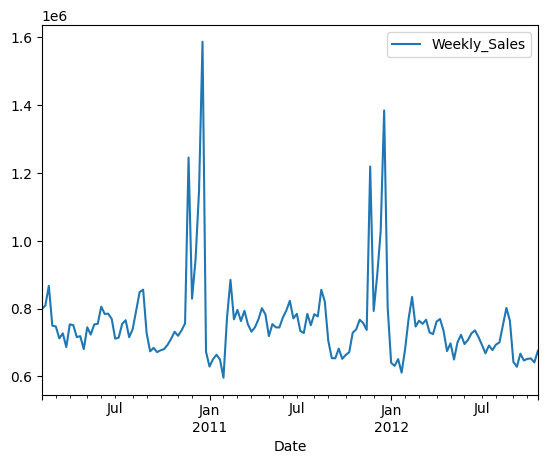

In [58]:
df2.plot()

In [59]:
# Checking for Stationarity of the data
result=adfuller(df2['Weekly_Sales'])
result[1]

np.float64(2.159382229855235e-06)

In [60]:
if result[1]>0.05:
  print("Data is not stationary")
else:
  print("Data is stationary")

Data is stationary


In [61]:
train=df2[:125]
test=df2[125:]

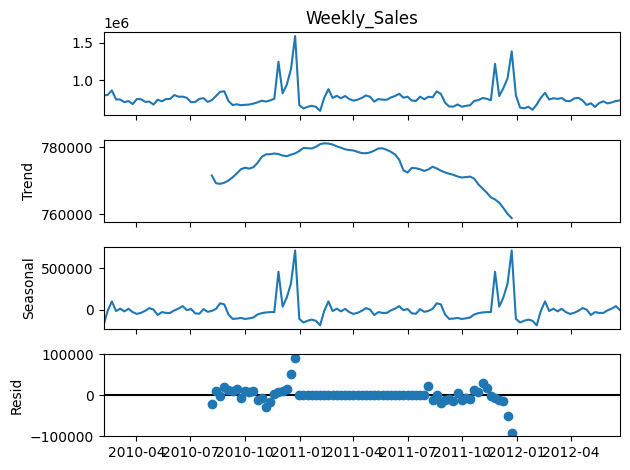

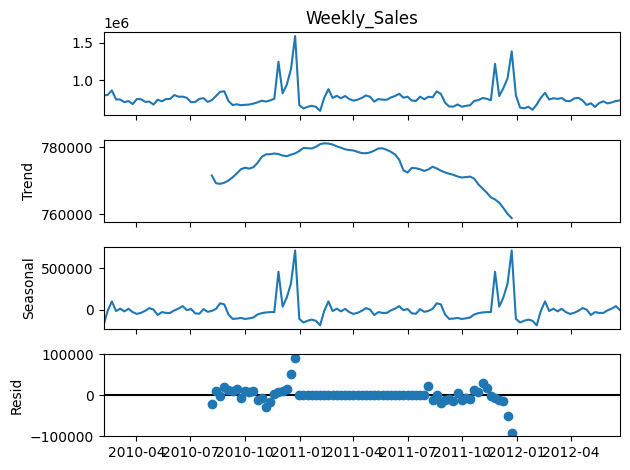

In [62]:
#seasonal decomposition
seasonal_decompose(train['Weekly_Sales']).plot()

### Autocorrelation Function (ACF) Plot (gives q value)

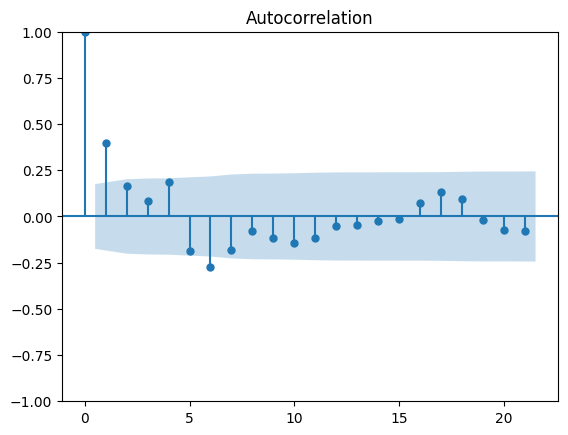

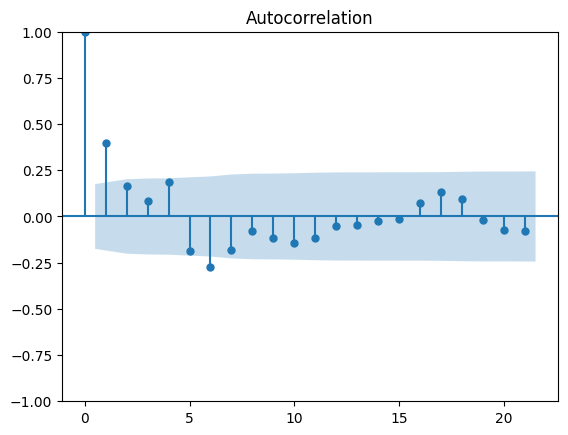

In [63]:
plot_acf(train)

### - Partial Autocorrelation Function (PACF) Plot  (gives p value)

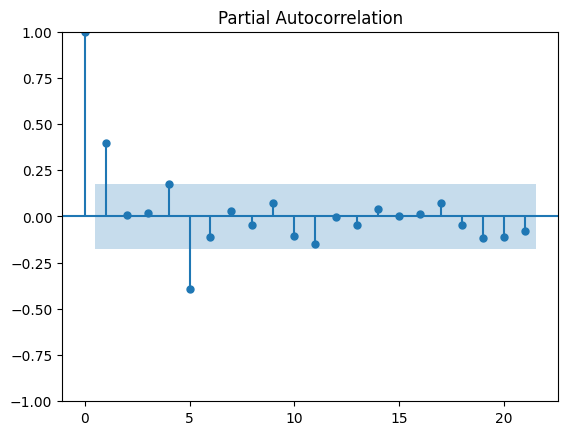

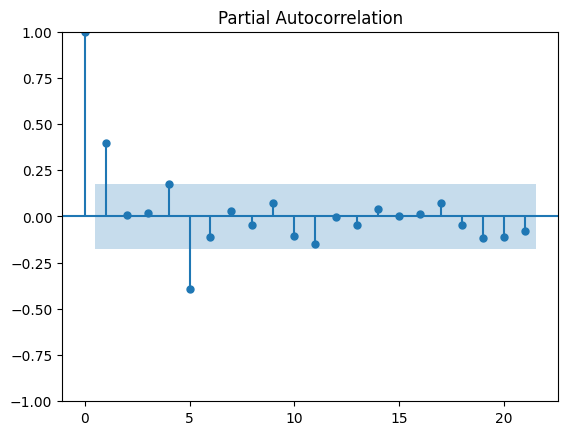

In [64]:
plot_pacf(train)

# **Model Building**

### Seasonal Autoregressive Integrated Moving Average (SARIMA) Method

In [65]:
# Note: We know that the seasonality period in the data is 'm = 52'
sarima_model = SARIMAX(train, order = (1, 0, 1), seasonal_order = (1, 0, 1, 52))
sarima_model = sarima_model.fit()

In [66]:
# Obtain predictions from the SARIMA model for the testing data indices
train_len = 125
sarima_model_preds = sarima_model.predict(start = train_len, end = len(df2) - 1)
sarima_model_preds

,predicted_mean
2012-06-29,716244.719481
2012-07-06,683208.733450
2012-07-13,678195.266047
2012-07-20,710062.903761
2012-07-27,686291.447615
2012-08-03,704129.751725
2012-08-10,699009.351484
2012-08-17,745626.478840
2012-08-24,722636.440250
2012-08-31,647315.857063


Let's visualize the predictions along with the data before computing error measures.

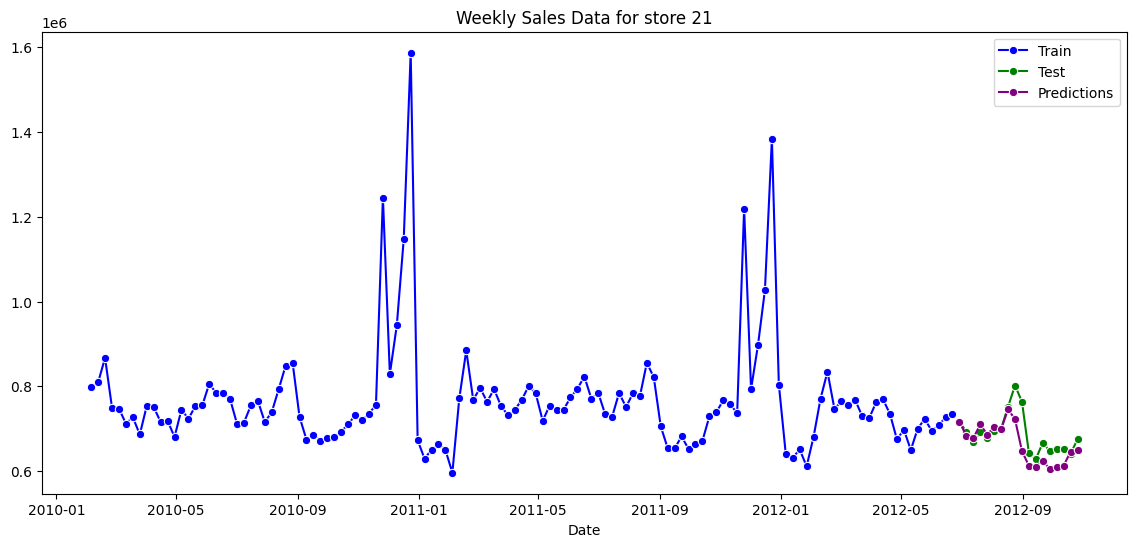

In [67]:
# Plot the time series data with the train-test split and the testing data predictions
plt.figure(figsize = (14, 6))
sns.lineplot(x = train.index, y = train['Weekly_Sales'].values, marker = 'o', color = 'blue', label = 'Train')
sns.lineplot(x = test.index, y = test['Weekly_Sales'].values, marker = 'o', color = 'green', label = 'Test')
sns.lineplot(x = sarima_model_preds.index, y = sarima_model_preds.values, marker = 'o', color = 'purple', label = 'Predictions')
plt.title('Weekly Sales Data for store 21');

Next, let's compute performance metrics for the model.

In [68]:
# Summarize the performance of the model on the test data using RMSE and MAPE
rmse = np.sqrt(mean_squared_error( test,sarima_model_preds))

rmse = np.round(rmse, 2)

performance_df_temp = pd.DataFrame(index = [0], data = {'Model': 'SARIMA(for store 21)', 'RMSE': rmse})

performance_df_temp.set_index('Model', inplace = True)

performance_df = pd.concat([performance_df, performance_df_temp])

performance_df.drop_duplicates(inplace = True)
performance_df

,RMSE
Model,
AR,93805.31
ARIMA,93643.70
SARIMA (for store 2),71022.96
SARIMA(for store 21),40489.66


In [69]:
# Generate the forecast for 12 steps
future_forecast = sarima_model.forecast(steps=12)

# Create a date range starting from '2012-11-02' with weekly frequency for 12 periods
future_dates = pd.date_range(start='2012-11-02', periods=12, freq='W-FRI')

# Assign the new dates as the index for the future forecast
future_forecast.index = future_dates

# Display the future forecast with the desired dates
print("12-Week Forecast starting from 2012-11-02:")
print(future_forecast)

12-Week Forecast starting from 2012-11-02:
2012-11-02    716244.719481
2012-11-09    683208.733450
2012-11-16    678195.266047
2012-11-23    710062.903761
2012-11-30    686291.447615
2012-12-07    704129.751725
2012-12-14    699009.351484
2012-12-21    745626.478840
2012-12-28    722636.440250
2013-01-04    647315.857063
2013-01-11    612555.653281
2013-01-18    610295.380197
Freq: W-FRI, Name: predicted_mean, dtype: float64


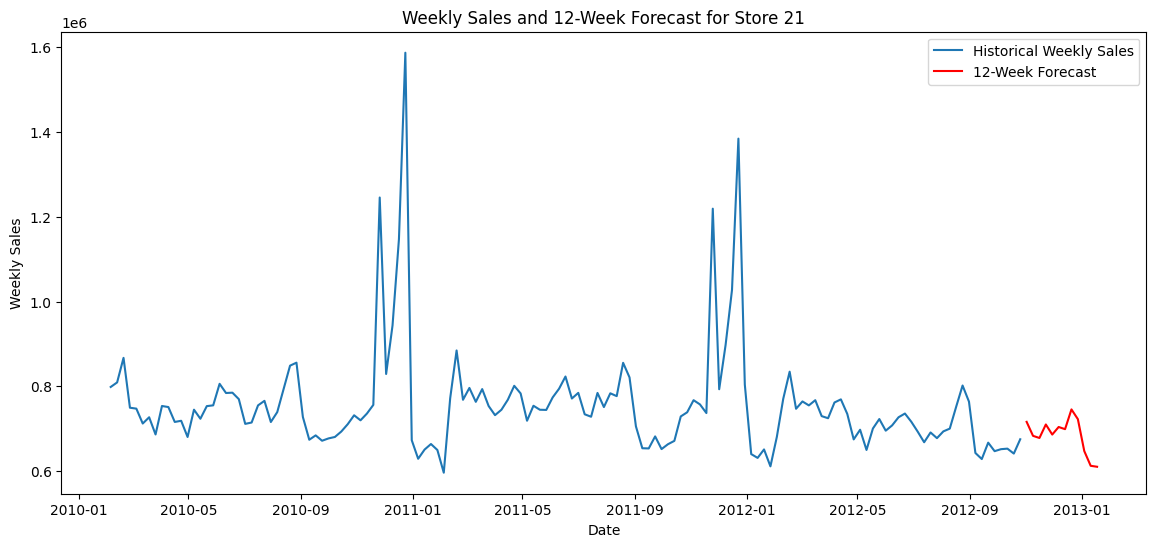

In [70]:
# Plot the historical weekly sales and the 12-week forecast
plt.figure(figsize=(14, 6))
plt.plot(df2.index, df2['Weekly_Sales'], label='Historical Weekly Sales')
plt.plot(future_forecast.index, future_forecast, label='12-Week Forecast', color='red')
plt.title('Weekly Sales and 12-Week Forecast for Store 21')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.legend()
plt.show()

**-----------------------------------------------------------**

#**3. Time Series forecasting for Store 16**

In [71]:
# Sorting data for Store 16
df3=df[df['Store']==16][['Date',"Weekly_Sales"]]
df3

,Date,Weekly_Sales
2145,2010-02-05,477409.30
2146,2010-02-12,472044.28
2147,2010-02-19,469868.70
2148,2010-02-26,443242.17
2149,2010-03-05,444181.85
...,...,...
2283,2012-09-28,469607.73
2284,2012-10-05,471281.68
2285,2012-10-12,491817.19
2286,2012-10-19,577198.97


In [72]:
df3['Date'] = pd.to_datetime(df3['Date'])
df3.reset_index(drop = True, inplace = True)

In [73]:
df3.set_index('Date', inplace = True)

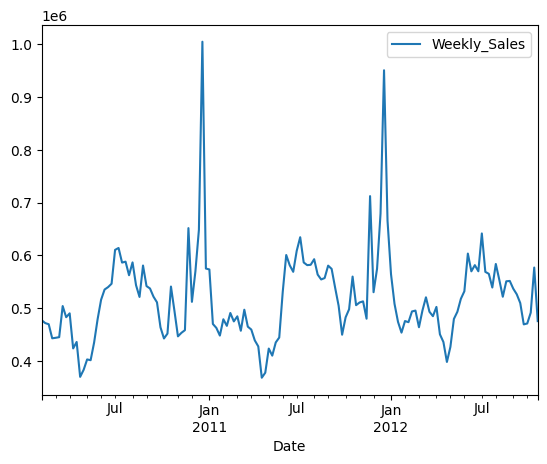

In [74]:
df3.plot();

In [75]:
# Checking Stationarity of the data
result=adfuller(df3['Weekly_Sales'])
result[1]

np.float64(0.00017660674414720552)

In [76]:
if result[1]>0.05:
  print("Data is not stationary")
else:
  print("Data is stationary")

Data is stationary


In [77]:
# Dividing data into training and testing
train=df3[:125]
test=df3[125:]

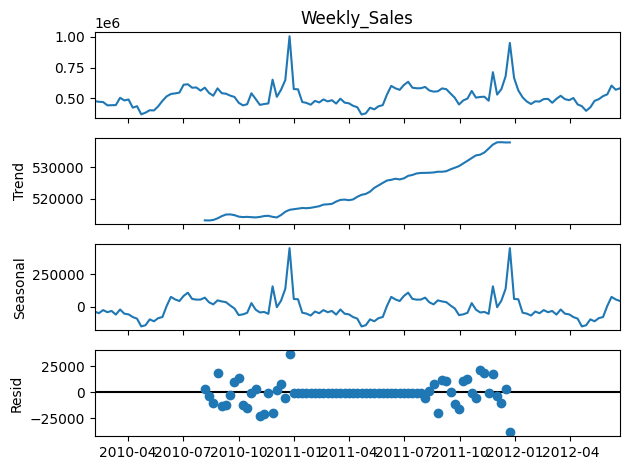

In [78]:
#seasonal decomposition
seasonal_decompose(train['Weekly_Sales']).plot();

### Autocorrelation Function (ACF) Plot (gives q value)

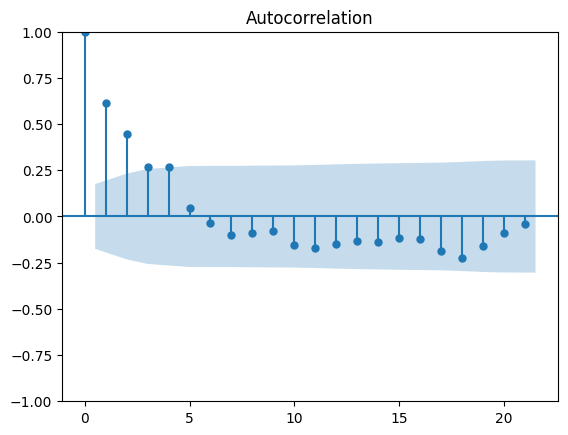

In [79]:
plot_acf(train);

### - Partial Autocorrelation Function (PACF) Plot  (gives p value)

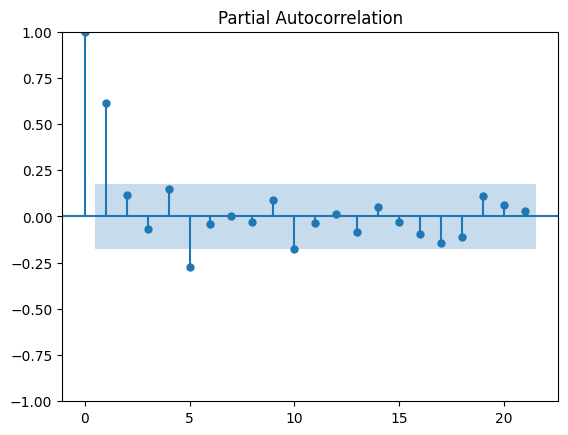

In [80]:
plot_pacf(train);

# **Model Building**

### Seasonal Autoregressive Integrated Moving Average (SARIMA) Method

In [81]:
# Note: We know that the seasonality period in the data is 'm = 52'
sarima_model = SARIMAX(train, order = (1, 0, 1), seasonal_order = (1, 0, 1, 52))
sarima_model = sarima_model.fit()


In [82]:
# Obtain predictions from the SARIMA model for the testing data indices
train_len = 125
sarima_model_preds = sarima_model.predict(start = train_len, end = len(df3) - 1)
sarima_model_preds

,predicted_mean
2012-06-29,597160.782502
2012-07-06,610719.906626
2012-07-13,578138.099730
2012-07-20,572505.518381
2012-07-27,570061.728702
2012-08-03,574538.132337
2012-08-10,553464.245077
2012-08-17,545027.531784
2012-08-24,545169.602198
2012-08-31,556881.826543


Let's visualize the predictions along with the data before computing error measures.

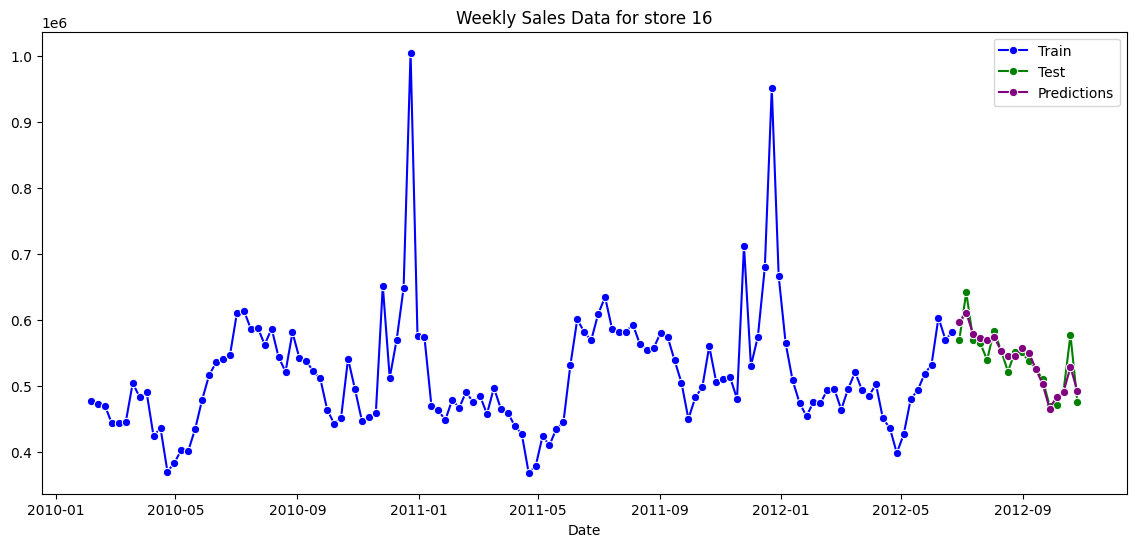

In [83]:
# Plot the time series data with the train-test split and the testing data predictions
plt.figure(figsize = (14, 6))
sns.lineplot(x = train.index, y = train['Weekly_Sales'].values, marker = 'o', color = 'blue', label = 'Train')
sns.lineplot(x = test.index, y = test['Weekly_Sales'].values, marker = 'o', color = 'green', label = 'Test')
sns.lineplot(x = sarima_model_preds.index, y = sarima_model_preds.values, marker = 'o', color = 'purple', label = 'Predictions')
plt.title('Weekly Sales Data for store 16');

Next, let's compute performance metrics for the model.

In [84]:
# Summarize the performance of the model on the test data using RMSE and MAPE
rmse = np.sqrt(mean_squared_error( test,sarima_model_preds))

rmse = np.round(rmse, 2)

performance_df_temp = pd.DataFrame(index = [0], data = {'Model': 'SARIMA(for store 16)', 'RMSE': rmse})

performance_df_temp.set_index('Model', inplace = True)

performance_df = pd.concat([performance_df, performance_df_temp])

performance_df.drop_duplicates(inplace = True)
performance_df

,RMSE
Model,
AR,93805.31
ARIMA,93643.70
SARIMA (for store 2),71022.96
SARIMA(for store 21),40489.66
SARIMA(for store 16),19004.62


In [85]:
# Generate the forecast for 12 steps
future_forecast = sarima_model.forecast(steps=12)

# Create a date range starting from '2012-11-02' with weekly frequency for 12 periods
future_dates = pd.date_range(start='2012-11-02', periods=12, freq='W-FRI')

# Assign the new dates as the index for the future forecast
future_forecast.index = future_dates

# Display the future forecast with the desired dates
print("12-Week Forecast starting from 2012-11-02:")
print(future_forecast)

12-Week Forecast starting from 2012-11-02:
2012-11-02    597160.782502
2012-11-09    610719.906626
2012-11-16    578138.099730
2012-11-23    572505.518381
2012-11-30    570061.728702
2012-12-07    574538.132337
2012-12-14    553464.245077
2012-12-21    545027.531784
2012-12-28    545169.602198
2013-01-04    556881.826543
2013-01-11    550684.138288
2013-01-18    526140.883141
Freq: W-FRI, Name: predicted_mean, dtype: float64


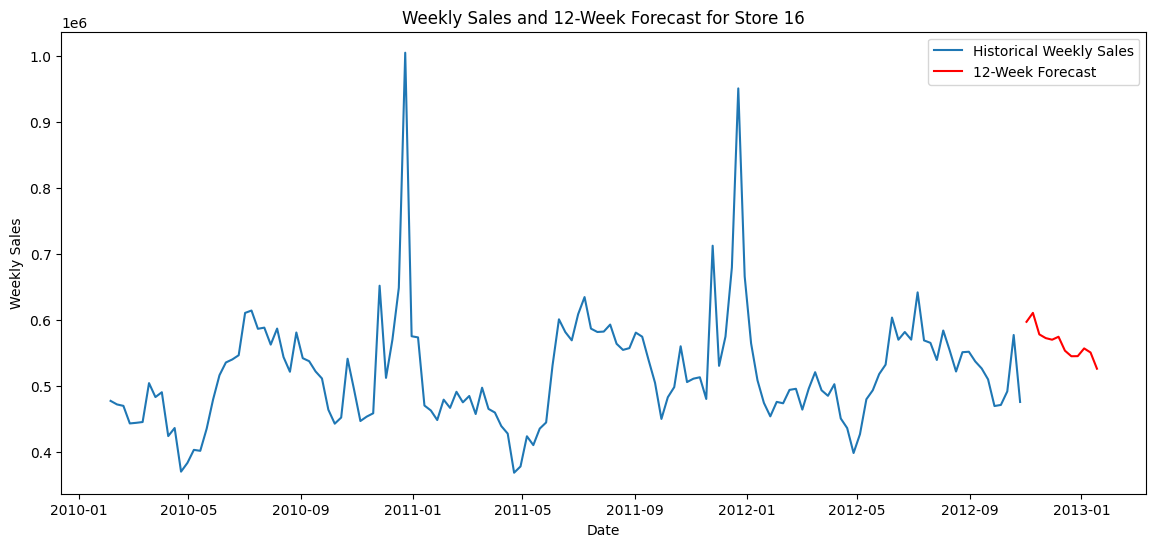

In [86]:
# Plot the historical weekly sales and the 12-week forecast
plt.figure(figsize=(14, 6))
plt.plot(df3.index, df3['Weekly_Sales'], label='Historical Weekly Sales')
plt.plot(future_forecast.index, future_forecast, label='12-Week Forecast', color='red')
plt.title('Weekly Sales and 12-Week Forecast for Store 16')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.legend()
plt.show()

**----------------------------------------------------------**

#**4. Time Series forecasting for Store 35**

In [87]:
# Sorting data for Store 35
df4=df[df['Store']==35][['Date',"Weekly_Sales"]]
df4

,Date,Weekly_Sales
4862,2010-02-05,1230613.50
4863,2010-02-12,1168815.31
4864,2010-02-19,1270658.64
4865,2010-02-26,1020651.74
4866,2010-03-05,1162610.27
...,...,...
5000,2012-09-28,814099.86
5001,2012-10-05,866064.40
5002,2012-10-12,873643.14
5003,2012-10-19,829284.67


In [88]:
df4['Date'] = pd.to_datetime(df4['Date'])
df4.reset_index(drop = True, inplace = True)

In [89]:
df4.set_index('Date', inplace = True)

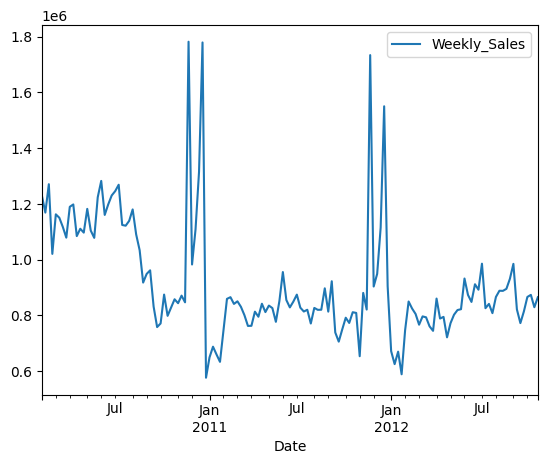

In [90]:
df4.plot();

In [91]:
# Checking Stationarity of the data
result=adfuller(df4['Weekly_Sales'])
result[1]

np.float64(0.004233729927299902)

In [92]:
if result[1]>0.05:
  print("Data is not stationary")
else:
  print("Data is stationary")

Data is stationary


In [93]:
train=df4[:125]
test=df4[125:]

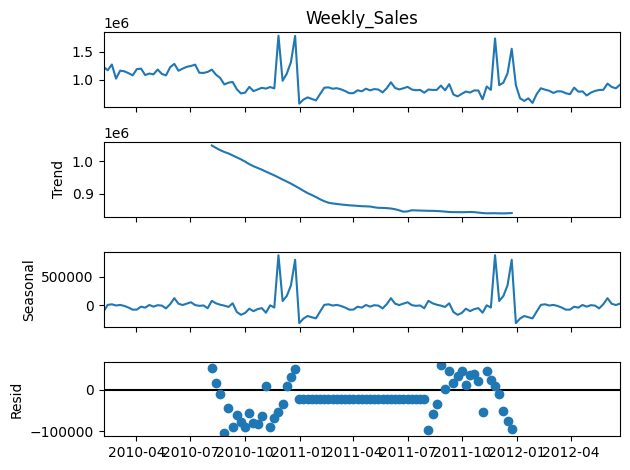

In [94]:
#seasonal decomposition
seasonal_decompose(train['Weekly_Sales']).plot();

### Autocorrelation Function (ACF) Plot (gives q value)

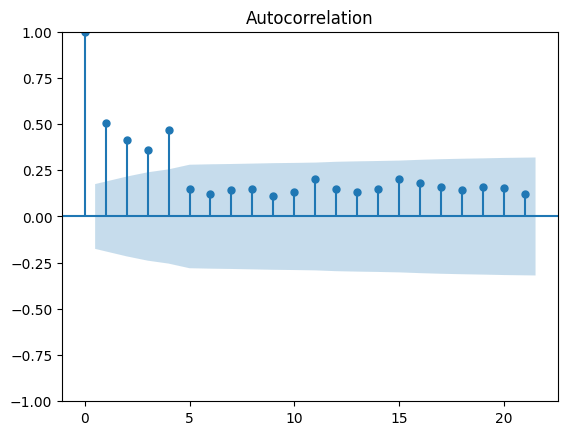

In [95]:
plot_acf(train);

### - Partial Autocorrelation Function (PACF) Plot  (gives p value)

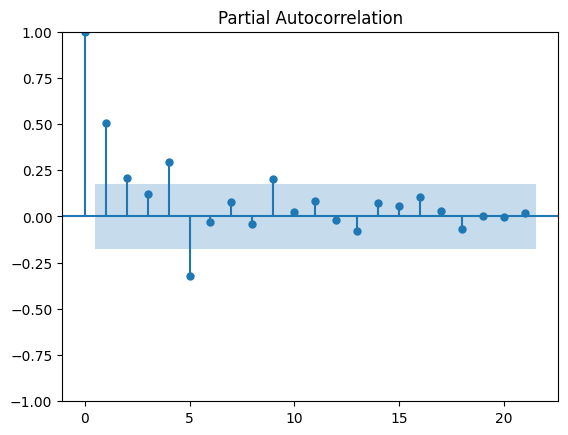

In [96]:
plot_pacf(train);

#**Model Building**

### Seasonal Autoregressive Integrated Moving Average (SARIMA) Method

In [97]:
# Note: We know that the seasonality period in the data is 'm = 52'
sarima_model = SARIMAX(train, order = (1, 0, 1), seasonal_order = (1, 0, 1, 52))
sarima_model = sarima_model.fit()


In [98]:
# Obtain predictions from the SARIMA model for the testing data indices
train_len = 125
sarima_model_preds = sarima_model.predict(start = train_len, end = len(df4) - 1)
sarima_model_preds

,predicted_mean
2012-06-29,884925.751849
2012-07-06,854158.005493
2012-07-13,840410.960139
2012-07-20,841181.190243
2012-07-27,808821.516331
2012-08-03,840216.045649
2012-08-10,831666.427431
2012-08-17,828062.504456
2012-08-24,869415.447257
2012-08-31,816865.058481


Let's visualize the predictions along with the data before computing error measures.

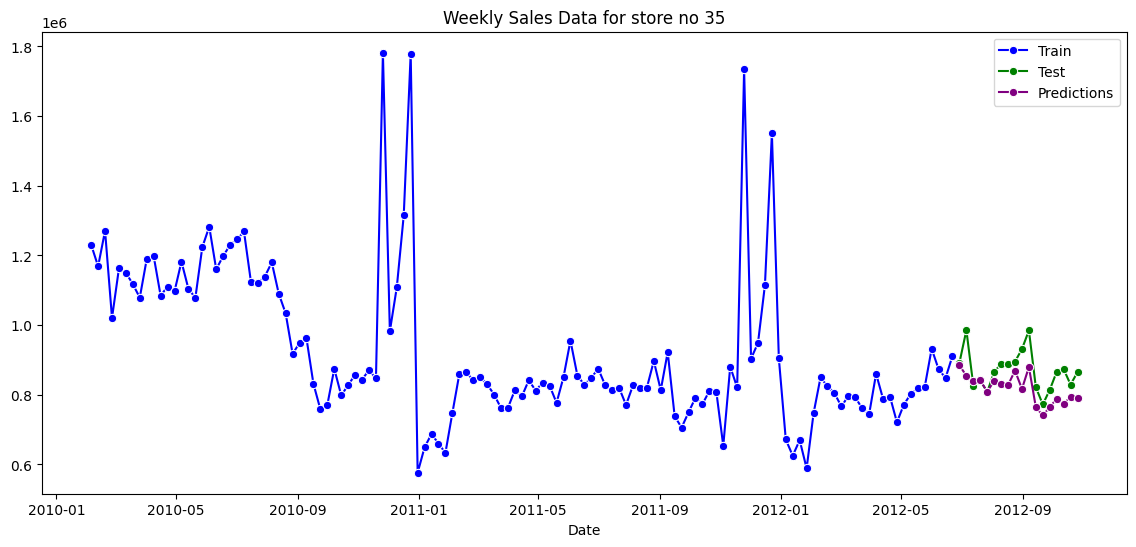

In [99]:
# Plot the time series data with the train-test split and the testing data predictions
plt.figure(figsize = (14, 6))
sns.lineplot(x = train.index, y = train['Weekly_Sales'].values, marker = 'o', color = 'blue', label = 'Train')
sns.lineplot(x = test.index, y = test['Weekly_Sales'].values, marker = 'o', color = 'green', label = 'Test')
sns.lineplot(x = sarima_model_preds.index, y = sarima_model_preds.values, marker = 'o', color = 'purple', label = 'Predictions')
plt.title('Weekly Sales Data for store no 35');

Next, let's compute performance metrics for the model.

In [100]:
# Summarize the performance of the model on the test data using RMSE and MAPE
rmse = np.sqrt(mean_squared_error( test,sarima_model_preds))

rmse = np.round(rmse, 2)

performance_df_temp = pd.DataFrame(index = [0], data = {'Model': 'SARIMA(for store 35)', 'RMSE': rmse})

performance_df_temp.set_index('Model', inplace = True)

performance_df = pd.concat([performance_df, performance_df_temp])

performance_df.drop_duplicates(inplace = True)
performance_df

,RMSE
Model,
AR,93805.31
ARIMA,93643.70
SARIMA (for store 2),71022.96
SARIMA(for store 21),40489.66
SARIMA(for store 16),19004.62
SARIMA(for store 35),66373.89


In [101]:
# Generate the forecast for 12 steps
future_forecast = sarima_model.forecast(steps=12)

# Create a date range starting from '2012-11-02' with weekly frequency for 12 periods
future_dates = pd.date_range(start='2012-11-02', periods=12, freq='W-FRI')

# Assign the new dates as the index for the future forecast
future_forecast.index = future_dates

# Display the future forecast with the desired dates
print("12-Week Forecast starting from 2012-11-02:")
print(future_forecast)

12-Week Forecast starting from 2012-11-02:
2012-11-02    884925.751849
2012-11-09    854158.005493
2012-11-16    840410.960139
2012-11-23    841181.190243
2012-11-30    808821.516331
2012-12-07    840216.045649
2012-12-14    831666.427431
2012-12-21    828062.504456
2012-12-28    869415.447257
2013-01-04    816865.058481
2013-01-11    879757.939667
2013-01-18    764429.594958
Freq: W-FRI, Name: predicted_mean, dtype: float64


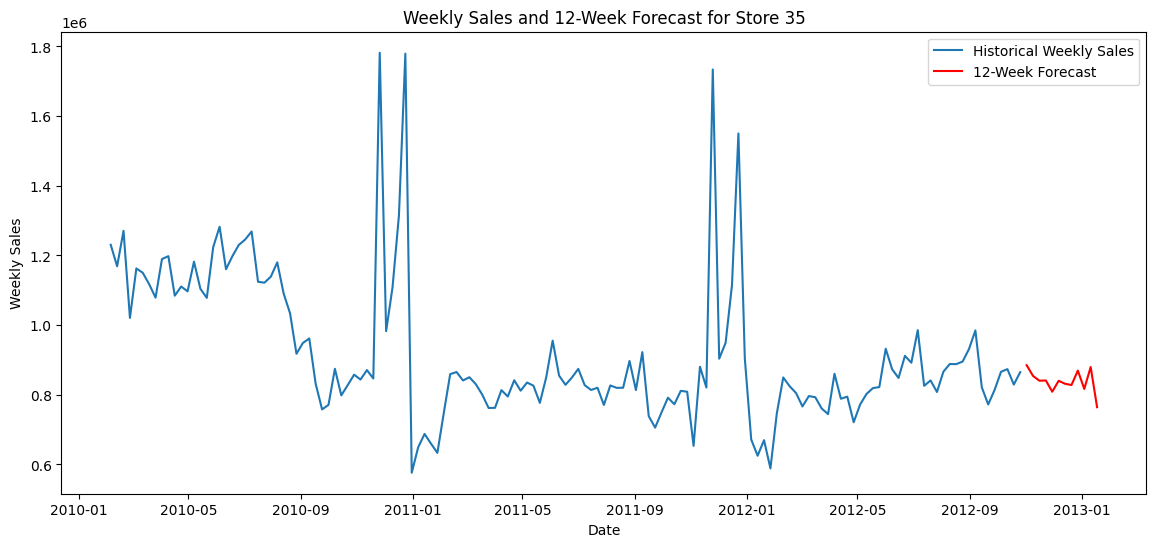

In [102]:
# Plot the historical weekly sales and the 12-week forecast
plt.figure(figsize=(14, 6))
plt.plot(df4.index, df4['Weekly_Sales'], label='Historical Weekly Sales')
plt.plot(future_forecast.index, future_forecast, label='12-Week Forecast', color='red')
plt.title('Weekly Sales and 12-Week Forecast for Store 35')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.legend()
plt.show()

**-----------------------------------------------------------**

#**5. Time Series forecasting for Store 27**

In [103]:
# Sorting data for Store 27
df5=df[df['Store']==27][['Date',"Weekly_Sales"]]
df5

,Date,Weekly_Sales
3718,2010-02-05,1874289.79
3719,2010-02-12,1745362.72
3720,2010-02-19,1945070.33
3721,2010-02-26,1390934.27
3722,2010-03-05,1313729.72
...,...,...
3856,2012-09-28,1540687.63
3857,2012-10-05,1591816.88
3858,2012-10-12,1660081.29
3859,2012-10-19,1620374.24


In [104]:
df5['Date'] = pd.to_datetime(df5['Date'])
df5.reset_index(drop = True, inplace = True)

In [105]:
df5.set_index('Date', inplace = True)

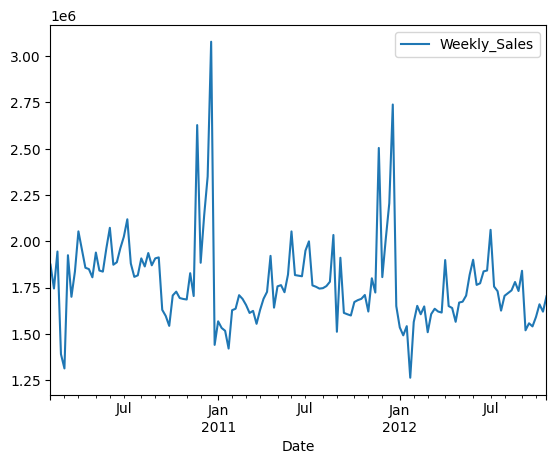

In [106]:
df5.plot();

In [107]:
# Checking Stationarity of the data
result=adfuller(df5['Weekly_Sales'])
result[1]

np.float64(6.821221055631735e-06)

In [108]:
if result[1]>0.05:
  print("Data is not stationary")
else:
  print("Data is stationary")

Data is stationary


In [109]:
# Dividing data into training and testing
train=df5[:125]
test=df5[125:]

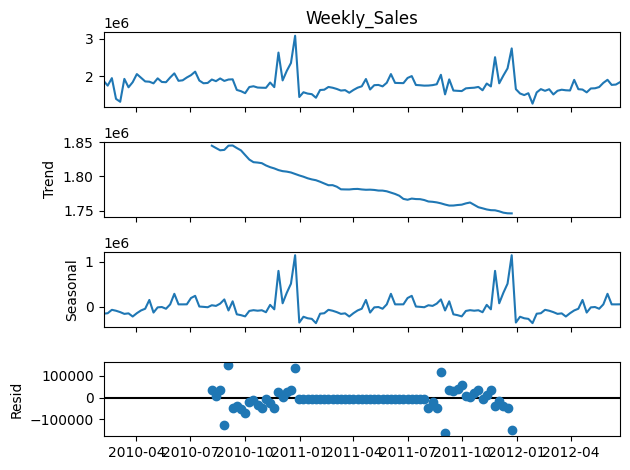

In [110]:
#seasonal decomposition
seasonal_decompose(train['Weekly_Sales']).plot();

### Autocorrelation Function (ACF) Plot (gives q value)

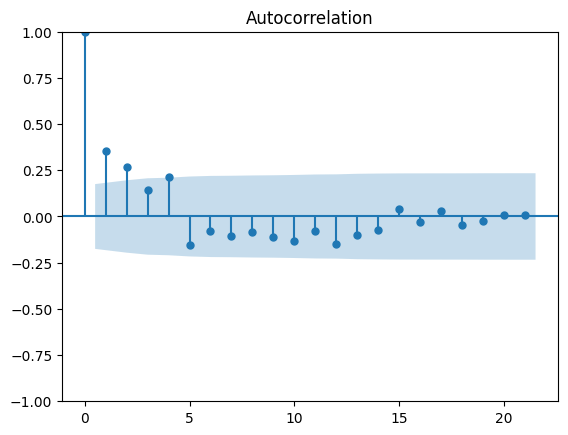

In [111]:
plot_acf(train);

### - Partial Autocorrelation Function (PACF) Plot  (gives p value)

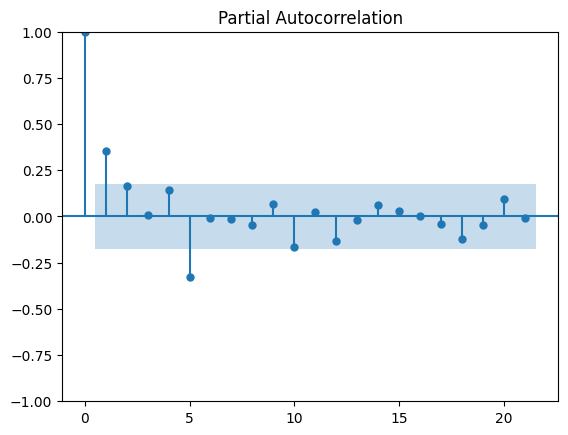

In [112]:
plot_pacf(train);

#**Model Building**

### Seasonal Autoregressive Integrated Moving Average (SARIMA) Method

In [113]:
# Note: We know that the seasonality period in the data is 'm = 52'
sarima_model = SARIMAX(train, order = (1, 0, 1), seasonal_order = (1, 0, 1, 52))
sarima_model = sarima_model.fit()


In [114]:
# Obtain predictions from the SARIMA model for the testing data indices
train_len = 125
sarima_model_preds = sarima_model.predict(start = train_len, end = len(df5) - 1)
sarima_model_preds

,predicted_mean
2012-06-29,1.857828e+06
2012-07-06,1.887330e+06
2012-07-13,1.738827e+06
2012-07-20,1.728555e+06
2012-07-27,1.720234e+06
2012-08-03,1.722578e+06
2012-08-10,1.724063e+06
2012-08-17,1.737574e+06
2012-08-24,1.875246e+06
2012-08-31,1.576944e+06


Let's visualize the predictions along with the data before computing error measures.

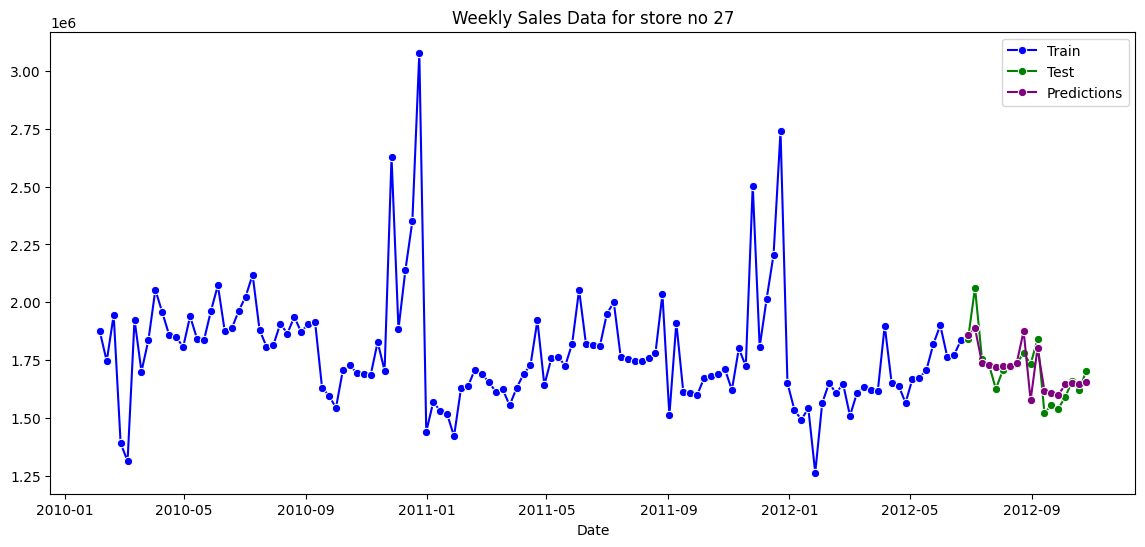

In [115]:
# Plot the time series data with the train-test split and the testing data predictions
plt.figure(figsize = (14, 6))
sns.lineplot(x = train.index, y = train['Weekly_Sales'].values, marker = 'o', color = 'blue', label = 'Train')
sns.lineplot(x = test.index, y = test['Weekly_Sales'].values, marker = 'o', color = 'green', label = 'Test')
sns.lineplot(x = sarima_model_preds.index, y = sarima_model_preds.values, marker = 'o', color = 'purple', label = 'Predictions')
plt.title('Weekly Sales Data for store no 27');

Next, let's compute performance metrics for the model.

In [116]:
# Summarize the performance of the model on the test data using RMSE and MAPE
rmse = np.sqrt(mean_squared_error( test,sarima_model_preds))

rmse = np.round(rmse, 2)

performance_df_temp = pd.DataFrame(index = [0], data = {'Model': 'SARIMA(for store 27)', 'RMSE': rmse})

performance_df_temp.set_index('Model', inplace = True)

performance_df = pd.concat([performance_df, performance_df_temp])

performance_df.drop_duplicates(inplace = True)
performance_df

,RMSE
Model,
AR,93805.31
ARIMA,93643.70
SARIMA (for store 2),71022.96
SARIMA(for store 21),40489.66
SARIMA(for store 16),19004.62
SARIMA(for store 35),66373.89
SARIMA(for store 27),73148.87


In [117]:
# Generate the forecast for 12 steps
future_forecast = sarima_model.forecast(steps=12)

# Create a date range starting from '2012-11-02' with weekly frequency for 12 periods
future_dates = pd.date_range(start='2012-11-02', periods=12, freq='W-FRI')

# Assign the new dates as the index for the future forecast
future_forecast.index = future_dates

# Display the future forecast with the desired dates
print("12-Week Forecast starting from 2012-11-02:")
print(future_forecast)

12-Week Forecast starting from 2012-11-02:
2012-11-02    1.857828e+06
2012-11-09    1.887330e+06
2012-11-16    1.738827e+06
2012-11-23    1.728555e+06
2012-11-30    1.720234e+06
2012-12-07    1.722578e+06
2012-12-14    1.724063e+06
2012-12-21    1.737574e+06
2012-12-28    1.875246e+06
2013-01-04    1.576944e+06
2013-01-11    1.801408e+06
2013-01-18    1.617106e+06
Freq: W-FRI, Name: predicted_mean, dtype: float64


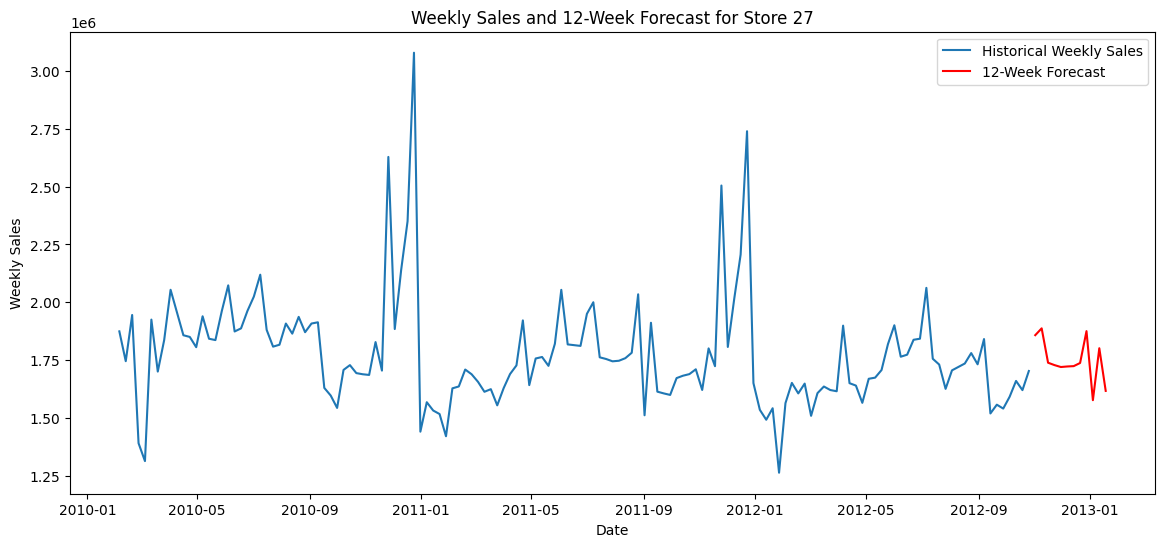

In [118]:
# Plot the historical weekly sales and the 12-week forecast
plt.figure(figsize=(14, 6))
plt.plot(df3.index, df5['Weekly_Sales'], label='Historical Weekly Sales')
plt.plot(future_forecast.index, future_forecast, label='12-Week Forecast', color='red')
plt.title('Weekly Sales and 12-Week Forecast for Store 27')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.legend()
plt.show()